<a href="https://colab.research.google.com/github/athiqhahammad2-art/-Agriculture-Smart-Farming---Computer-Vision-for-Crop-Disease-Detection-/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 1: Data Loading and Preprocessing

To begin, we need to set up the Kaggle API to download the dataset. This involves installing and configuring the Kaggle API client using your personal API token.

In [2]:
# 1. Install Kaggle API client
!pip install kaggle

# 2. Make a directory for Kaggle and save your API token

# The API token provided by Kaggle was: KGAT_5f747101916c51a4c69585d4cb771f72
!mkdir -p ~/.kaggle
!echo '{"username":"priyankayadav3","key":"KGAT_5f747101916c51a4c69585d4cb771f72"}' > ~/.kaggle/kaggle.json

# 3. Set permissions for the API key file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete. Now you can download datasets directly.")

Kaggle API setup complete. Now you can download datasets directly.


### 2. Download and Unzip the Dataset

Now that the Kaggle API is configured, we can download the dataset directly into our Colab environment and then unzip it. We'll use the `plant-village-dataset-2024` dataset from Kaggle.

In [3]:
# 4. Download the dataset using the Kaggle API
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

print("Dataset download initiated. This might take a few minutes for a large dataset.")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:17<00:00, 122MB/s]

Dataset download initiated. This might take a few minutes for a large dataset.


In [4]:
# 5. Unzip the downloaded dataset
# The downloaded file is named 'plantvillage-dataset.zip'
# We'll unzip it into the './plantvillage_data' directory.
!unzip -q plantvillage-dataset.zip -d ./plantvillage_data

print("Dataset unzipped to ./plantvillage_data")
print("Now, we will proceed to load and preprocess the dataset.")

Dataset unzipped to ./plantvillage_data
Now, we will proceed to load and preprocess the dataset.


In [5]:
# Inspect the contents of the unzipped directory to find the actual data path
!ls -F ./plantvillage_data

'plantvillage dataset'/


### 3. Load and Preprocess Dataset

Now we'll load the images, apply transformations, and get an initial understanding of the dataset's structure, including class distribution and sample images.

Number of classes: 38
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotte

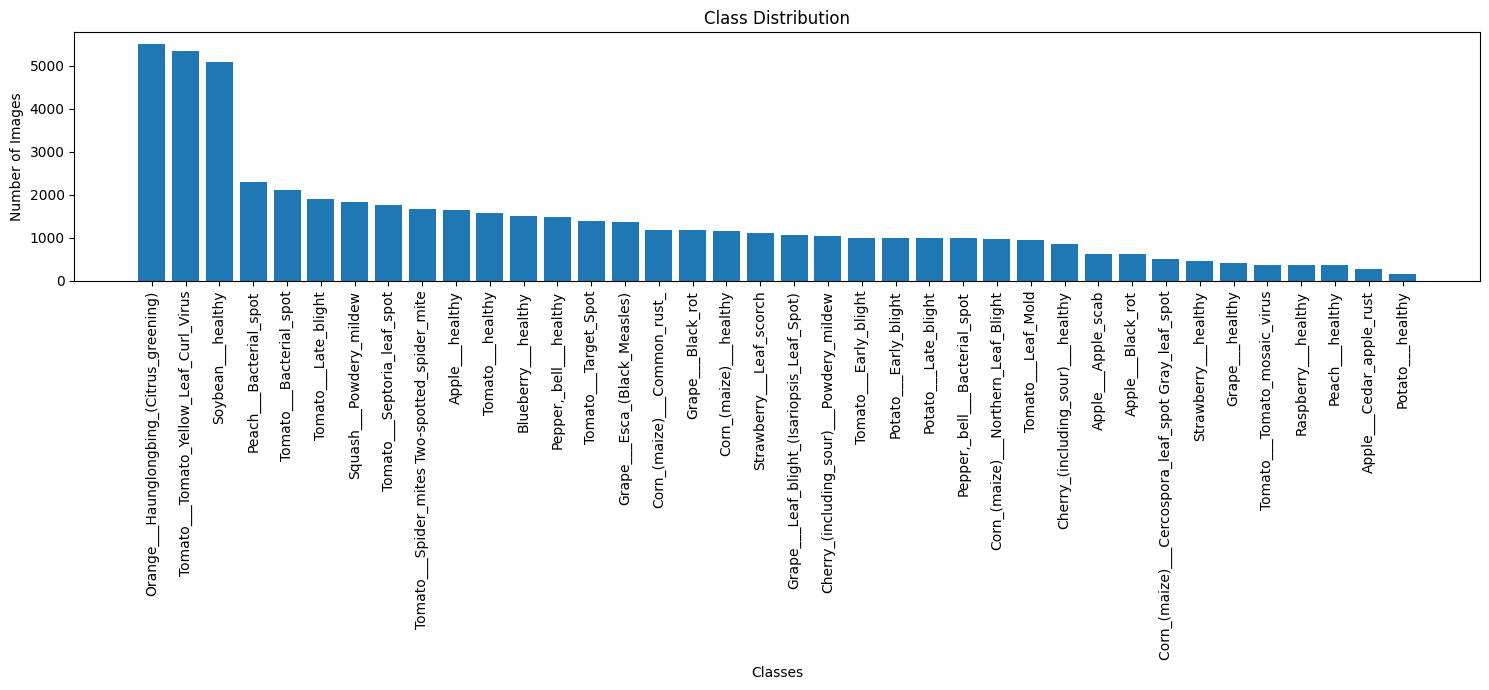

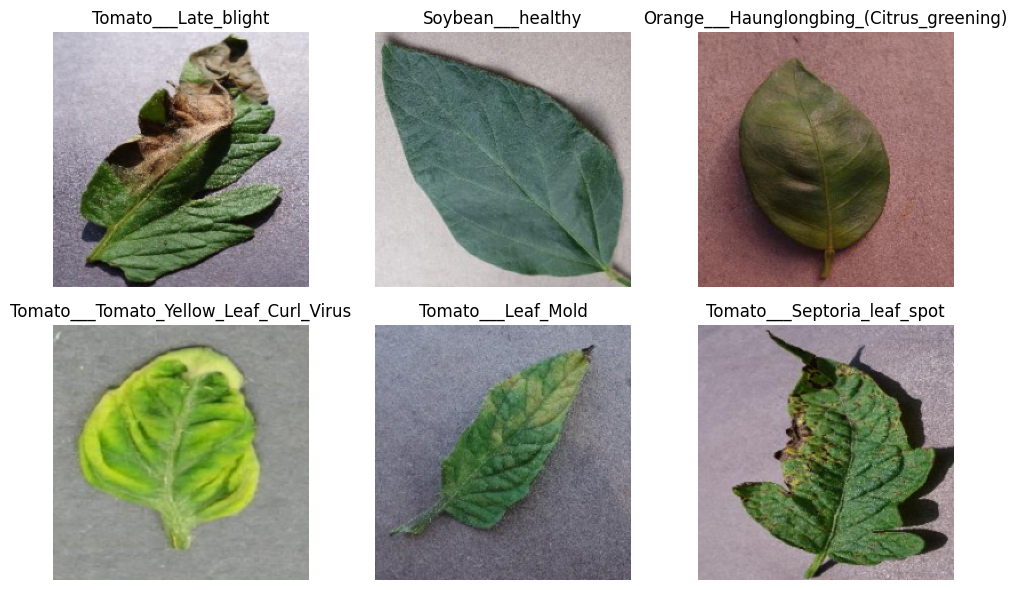

Dataset loaded and basic preprocessing applied. Transforms for augmentation and normalization are defined.


In [6]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 🔗 1. Set Dataset Path
data_path = "./plantvillage_data/plantvillage dataset/color" # Points to local unzipped data, adjusted for nested folder

# Define the mean and standard deviation for normalization (ImageNet statistics are common)
# These values are usually pre-calculated on large datasets like ImageNet
# If using a different dataset, these might need to be re-calculated.
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# -------------------------------
# 📊 2. Preprocessing for CNN
# -------------------------------
# Transforms for training data (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Random crop to 224x224, good for augmentation
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomRotation(10),      # Randomly rotate images by +/- 10 degrees
    transforms.ToTensor(),              # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean, std)     # Normalize pixel values
])

# Transforms for validation and test data (resizing and normalization only)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # Resize images to 224x224
    transforms.ToTensor(),              # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean, std)     # Normalize pixel values
])

# Load the dataset using ImageFolder with separate transforms for training and validation/test
# We'll apply `val_test_transform` to the full dataset temporarily to get class names and counts
# The actual train/val/test data will then get their appropriate transforms during DataLoader creation.
full_dataset = datasets.ImageFolder(root=data_path, transform=val_test_transform)

# Get class names and total number of classes
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# Calculate class counts from the full dataset (before split)
class_counts = {class_name: 0 for class_name in class_names}
for _, label_idx in full_dataset.samples:
    class_name = class_names[label_idx]
    class_counts[class_name] += 1

df_class_counts = pd.DataFrame(class_counts.items(), columns=["Class", "Count"])
df_class_counts = df_class_counts.sort_values(by="Count", ascending=False)

print("\nClass Distribution (Top 5):")
print(df_class_counts.head())

# -------------------------------
# 📊 3. Plot Class Distribution
# -------------------------------
plt.figure(figsize=(15, 7))
plt.bar(df_class_counts["Class"], df_class_counts["Count"])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# -------------------------------
# 🖼 4. Show Sample Images
# -------------------------------
plt.figure(figsize=(10, 6))

# Get a few random samples using the val_test_transform (no augmentation for display)
num_samples_to_show = 6
if len(full_dataset) < num_samples_to_show:
    num_samples_to_show = len(full_dataset)

for i in range(num_samples_to_show):
    idx = random.randint(0, len(full_dataset) - 1)
    img_tensor, label_idx = full_dataset[idx]
    # Undo normalization for display
    img_pil = transforms.ToPILImage()(img_tensor * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_pil)
    plt.title(class_names[label_idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Dataset loaded and basic preprocessing applied. Transforms for augmentation and normalization are defined.")

### 4. Split Data and Create DataLoaders

We'll split the dataset into 70% for training, 15% for validation, and 15% for testing. Then, we'll create PyTorch `DataLoader` instances for each set to manage batching and shuffling.

In [7]:
from torch.utils.data import random_split, Subset

# Define the split ratios
train_size = int(0.70 * len(full_dataset)) # Use full_dataset for initial split
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size # Ensure all data is covered

# Perform the random split on the full_dataset (which currently has val_test_transform applied)
train_indices, val_indices, test_indices = random_split(full_dataset, [train_size, val_size, test_size])

# Create Subset objects and apply the appropriate transforms
# Create a copy of the original dataset, then apply the specific transforms to the subsets.
# This ensures each subset uses its own transform.

# Create a new dataset instance for training with train_transform
train_dataset_with_aug = datasets.ImageFolder(root=data_path, transform=train_transform)
# Use the indices from the initial split to create the Subset
train_data = Subset(train_dataset_with_aug, train_indices.indices)

# Create new dataset instance for validation with val_test_transform
val_dataset_no_aug = datasets.ImageFolder(root=data_path, transform=val_test_transform)
val_data = Subset(val_dataset_no_aug, val_indices.indices)

# Create new dataset instance for test with val_test_transform
test_dataset_no_aug = datasets.ImageFolder(root=data_path, transform=val_test_transform)
test_data = Subset(test_dataset_no_aug, test_indices.indices)

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

# Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False) # No need to shuffle validation data
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False) # No need to shuffle test data

print("\nDataLoaders created with batch size:", batch_size)
print("✅ Dataset split and DataLoaders are ready, with augmentation for training and normalization for all.")

Training set size: 38013
Validation set size: 8145
Test set size: 8147

DataLoaders created with batch size: 32
✅ Dataset split and DataLoaders are ready, with augmentation for training and normalization for all.


### 5. Define Custom CNN Model

Now, we'll define the architecture for our custom Convolutional Neural Network (`CustomCNN`), including its layers, activation functions, and output. We'll also set up the `CrossEntropyLoss` criterion and the `Adam` optimizer.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms # Ensure these are imported for local dataset re-creation

# Define the expected data path for 38 classes. This should match where the ImageFolder was created.
expected_data_path = "./plantvillage_data/plantvillage dataset/color"

print(f"Ensuring 'dataset' is correctly initialized for 38 classes from: {expected_data_path}")

# Unconditionally re-initialize the dataset to ensure 'num_classes' is correct for this cell's execution.
# This prevents potential issues with the 'dataset' variable being in an incorrect state from previous executions.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(root=expected_data_path, transform=transform)

num_classes = len(dataset.classes)

if num_classes != 38:
    print(f"Error: After re-initialization, num_classes is still {num_classes}. Expected 38. Please check the '{expected_data_path}' directory structure.")
else:
    print(f"Number of classes for model: {num_classes}")

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Input channels = 3 (RGB)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), # Added another conv layer
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Calculate the size of the flattened features after conv layers
        # We'll pass a dummy tensor through the features to determine this
        self._to_linear = None
        self._get_conv_output_size()

        self.classifier = nn.Sequential(
            nn.Linear(self._to_linear, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Added dropout for regularization
            nn.Linear(512, num_classes)
        )

    def _get_conv_output_size(self):
        # Helper function to calculate the size of the output from the convolutional layers
        # This is needed to define the input size for the first fully connected layer
        dummy_input = torch.zeros(1, 3, 224, 224) # Batch size 1, 3 channels, 224x224 image
        output = self.features(dummy_input)
        self._to_linear = output.view(output.size(0), -1).size(1)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten the output for the fully connected layers
        x = self.classifier(x)
        return x

# Instantiate the model
model = CustomCNN(num_classes=num_classes)

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss() # Categorical Cross-Entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

# Print the model architecture
print("\nCustomCNN Model Architecture:")
print(model)
print("\n✅ CustomCNN model defined, loss function and optimizer set up.")


Ensuring 'dataset' is correctly initialized for 38 classes from: ./plantvillage_data/plantvillage dataset/color
Number of classes for model: 38

CustomCNN Model Architecture:
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=50176, out_features=512,

### 6. Training Loop and Evaluation (Week 2 Task)

In [9]:
#1. Set up training parameters
num_epochs = 10
# 2. Check for CUDA (GPU) availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Using device: {device}")

#3. Training Function
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs):
    train_losses = []
    val_losses = []
    val_accuracies = []

    print("Starting training...")  # Added this line to confirm training start
    for epoch in range(num_epochs):
        # Training Phase
        model.train()     # Set model to training mode
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()     # Zero the parameter gradients
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation Phase
        model.eval()    # Set model to evaluation mode
        running_val_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():  # Deactivate autograd for validation
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total_predictions += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        epoch_val_accuracy = 100 * correct_predictions / total_predictions
        val_accuracies.append(epoch_val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, "
              f"Val Acc: {epoch_val_accuracy:.2f}%")

    print("Training complete!")
    return train_losses, val_losses, val_accuracies
# 4. Start Training
train_losses, val_losses, val_accuracies = train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs)

Using device: cuda
Starting training...
Epoch 1/10 - Train Loss: 1.8410, Val Loss: 0.9623, Val Acc: 70.57%
Epoch 2/10 - Train Loss: 1.0501, Val Loss: 0.4745, Val Acc: 84.91%
Epoch 3/10 - Train Loss: 0.8221, Val Loss: 0.3819, Val Acc: 87.82%
Epoch 4/10 - Train Loss: 0.6954, Val Loss: 0.2684, Val Acc: 91.48%
Epoch 5/10 - Train Loss: 0.6276, Val Loss: 0.2357, Val Acc: 92.76%
Epoch 6/10 - Train Loss: 0.5641, Val Loss: 0.2398, Val Acc: 92.71%
Epoch 7/10 - Train Loss: 0.5415, Val Loss: 0.1738, Val Acc: 94.06%
Epoch 8/10 - Train Loss: 0.5041, Val Loss: 0.1862, Val Acc: 94.72%
Epoch 9/10 - Train Loss: 0.4658, Val Loss: 0.2281, Val Acc: 92.68%
Epoch 10/10 - Train Loss: 0.4738, Val Loss: 0.2022, Val Acc: 93.39%
Training complete!


Once the training is complete, we'll plot the training and validation loss, and validation accuracy over epochs to visualize the model's performance.

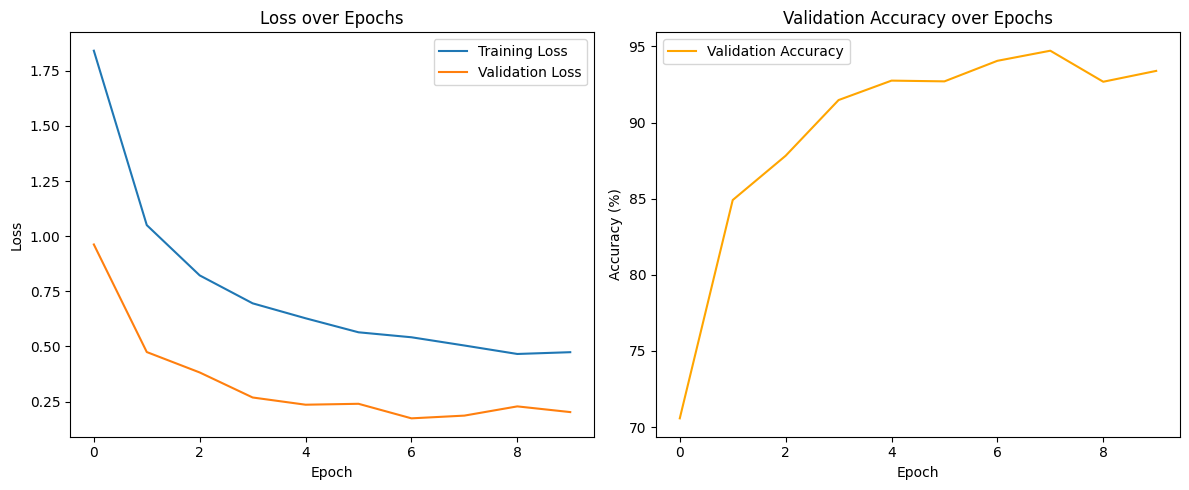

In [10]:
# 📈 5. Plotting Training History
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


### 6. Model Evaluation: Accuracy, Precision, and Recall

In [11]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Set the model to evaluation mode
model.eval()

# Initialize lists to store true labels and predictions
all_labels = []
all_predictions = []

# Disable gradient calculation for evaluation
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Calculate Accuracy
accuracy = accuracy_score(all_labels, all_predictions)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# Calculate Precision, Recall, and F1-Score per class
# Set `average=None` to get scores for each class
precision, recall, f1_score, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average=None, labels=range(num_classes)
)

# Create a DataFrame for per-class metrics
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score
})

print("\nPer-Class Metrics:")
display(metrics_df)

# Calculate overall (macro) Precision, Recall, F1-score
# 'macro' calculates metrics for each label, and finds their unweighted mean.
overall_precision, overall_recall, overall_f1_score, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average='macro', labels=range(num_classes)
)

print(f"\nOverall Macro Precision: {overall_precision:.4f}")
print(f"Overall Macro Recall: {overall_recall:.4f}")
print(f"Overall Macro F1-Score: {overall_f1_score:.4f}")



Test Accuracy: 92.82%

Per-Class Metrics:


,Class,Precision,Recall,F1-Score
0,Apple___Apple_scab,0.833333,0.842105,0.837696
1,Apple___Black_rot,0.968421,0.948454,0.958333
2,Apple___Cedar_apple_rust,1.000000,0.952381,0.975610
3,Apple___healthy,0.939271,0.950820,0.945010
4,Blueberry___healthy,0.906780,1.000000,0.951111
5,Cherry_(including_sour)___Powdery_mildew,0.965318,0.982353,0.973761
6,Cherry_(including_sour)___healthy,0.972727,0.963964,0.968326
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.978723,0.589744,0.736000
8,Corn_(maize)___Common_rust_,0.984043,0.994624,0.989305
9,Corn_(maize)___Northern_Leaf_Blight,0.802548,0.969231,0.878049



Overall Macro Precision: 0.9176
Overall Macro Recall: 0.9058
Overall Macro F1-Score: 0.9041


## Week 3: Transfer Learning and Hyperparameter Optimization

In this section, we will enhance our model by implementing Transfer Learning. This involves using a pre-trained Convolutional Neural Network (CNN) as a feature extractor and fine-tuning its final classification layers for our specific plant disease dataset. We will start with a ResNet50 model, freeze its convolutional base, and replace its original classification head with new layers tailored to our `num_classes`.

### 7. Implement Transfer Learning with ResNet50

We will load a pre-trained ResNet50 model, freeze its convolutional layers to retain the learned features, and replace its final fully connected layer to match the number of classes in our dataset. This approach leverages the powerful feature extraction capabilities of large models trained on vast datasets like ImageNet.

In [12]:
import torchvision.models as models

# Load a pre-trained ResNet50 model
resnet_model = models.resnet50(pretrained=True)

# Freeze all parameters in the feature-extracting layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (classification head)
# The number of input features to the last layer of ResNet50 is 2048
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, num_classes)

# Move the model to the appropriate device (GPU if available, else CPU)
resnet_model = resnet_model.to(device)

# Define the new optimizer, only optimizing the parameters of the new classification head
optimizer_ft = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

# Print the modified model architecture
print("\nResNet50 Model Architecture (Modified for Transfer Learning):")
print(resnet_model)
print("\n✅ ResNet50 model loaded, frozen, and classification head replaced.")
print("Only the final classification layer will be trained.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 127MB/s]



ResNet50 Model Architecture (Modified for Transfer Learning):
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequentia

### 8. Train the Transfer Learning Model

Now, we will train the ResNet50 model with its frozen base and fine-tuned classification head. We will use the same training function and evaluate its performance. This step will demonstrate the effectiveness of transfer learning in achieving higher accuracy with fewer epochs.

In [13]:
# Re-use the training function from Week 2
# It's important to pass the new model (resnet_model) and its corresponding optimizer (optimizer_ft)

print("Starting training for ResNet50 (Transfer Learning) model...")
resnet_train_losses, resnet_val_losses, resnet_val_accuracies = train_model(
    resnet_model, criterion, optimizer_ft, train_loader, val_loader, num_epochs=10
)

print("\nResNet50 Transfer Learning Training Complete!")

Starting training for ResNet50 (Transfer Learning) model...
Starting training...
Epoch 1/10 - Train Loss: 0.8987, Val Loss: 0.3434, Val Acc: 89.18%
Epoch 2/10 - Train Loss: 0.5287, Val Loss: 0.3119, Val Acc: 90.36%
Epoch 3/10 - Train Loss: 0.4705, Val Loss: 0.2995, Val Acc: 90.25%
Epoch 4/10 - Train Loss: 0.4439, Val Loss: 0.2242, Val Acc: 92.54%
Epoch 5/10 - Train Loss: 0.4258, Val Loss: 0.2091, Val Acc: 92.99%
Epoch 6/10 - Train Loss: 0.4092, Val Loss: 0.2529, Val Acc: 91.66%
Epoch 7/10 - Train Loss: 0.4018, Val Loss: 0.2413, Val Acc: 92.03%
Epoch 8/10 - Train Loss: 0.3885, Val Loss: 0.2367, Val Acc: 92.15%
Epoch 9/10 - Train Loss: 0.3809, Val Loss: 0.2450, Val Acc: 92.01%
Epoch 10/10 - Train Loss: 0.3796, Val Loss: 0.2229, Val Acc: 92.88%
Training complete!

ResNet50 Transfer Learning Training Complete!


### 9. Evaluate the Transfer Learning Model

After training the ResNet50 model, we will evaluate its performance using the test set. We will calculate the accuracy, precision, recall, and F1-score to compare with the custom CNN model.

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Set the ResNet model to evaluation mode
resnet_model.eval()

# Initialize lists to store true labels and predictions for ResNet
resnet_all_labels = []
resnet_all_predictions = []

# Disable gradient calculation for evaluation
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet_model(inputs)
        _, predicted = torch.max(outputs, 1)

        resnet_all_labels.extend(labels.cpu().numpy())
        resnet_all_predictions.extend(predicted.cpu().numpy())

# Calculate Accuracy for ResNet
resnet_accuracy = accuracy_score(resnet_all_labels, resnet_all_predictions)
print(f"\nResNet50 Test Accuracy: {resnet_accuracy*100:.2f}%")

# Calculate Precision, Recall, and F1-Score per class for ResNet
resnet_precision, resnet_recall, resnet_f1_score, _ = precision_recall_fscore_support(
    resnet_all_labels, resnet_all_predictions, average=None, labels=range(num_classes)
)

# Create a DataFrame for per-class metrics for ResNet
resnet_metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': resnet_precision,
    'Recall': resnet_recall,
    'F1-Score': resnet_f1_score
})

print("\nResNet50 Per-Class Metrics:")
display(resnet_metrics_df)

# Calculate overall (macro) Precision, Recall, F1-score for ResNet
resnet_overall_precision, resnet_overall_recall, resnet_overall_f1_score, _ = precision_recall_fscore_support(
    resnet_all_labels, resnet_all_predictions, average='macro', labels=range(num_classes)
)

print(f"\nResNet50 Overall Macro Precision: {resnet_overall_precision:.4f}")
print(f"ResNet50 Overall Macro Recall: {resnet_overall_recall:.4f}")
print(f"ResNet50 Overall Macro F1-Score: {resnet_overall_f1_score:.4f}")


ResNet50 Test Accuracy: 92.41%

ResNet50 Per-Class Metrics:


,Class,Precision,Recall,F1-Score
0,Apple___Apple_scab,0.903226,0.884211,0.893617
1,Apple___Black_rot,0.979798,1.000000,0.989796
2,Apple___Cedar_apple_rust,1.000000,0.928571,0.962963
3,Apple___healthy,0.951807,0.971311,0.961460
4,Blueberry___healthy,0.995261,0.981308,0.988235
5,Cherry_(including_sour)___Powdery_mildew,0.993631,0.917647,0.954128
6,Cherry_(including_sour)___healthy,0.972222,0.945946,0.958904
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.785714,0.846154,0.814815
8,Corn_(maize)___Common_rust_,0.915423,0.989247,0.950904
9,Corn_(maize)___Northern_Leaf_Blight,0.898305,0.815385,0.854839



ResNet50 Overall Macro Precision: 0.9210
ResNet50 Overall Macro Recall: 0.9041
ResNet50 Overall Macro F1-Score: 0.9069


### 10. Hyperparameter Tuning: Learning Rate Experiment

To further optimize our transfer learning model, we will perform a simple hyperparameter tuning experiment focusing on the learning rate. We'll train the ResNet50 model with a few different learning rates and observe their impact on validation accuracy. This will help us identify a better learning rate if one exists.

In [15]:
learning_rates = [0.0001, 0.001, 0.01]
num_epochs_tuning = 5 # Use fewer epochs for tuning to save time

results = {}

print("Starting Hyperparameter Tuning for Learning Rate...")

for lr in learning_rates:
    print(f"\n----- Training with Learning Rate: {lr} -----")

    # Re-instantiate the model to ensure a fresh start for each LR experiment
    # Make sure to freeze layers again
    tuned_model = models.resnet50(pretrained=True)
    for param in tuned_model.parameters():
        param.requires_grad = False
    num_ftrs = tuned_model.fc.in_features
    tuned_model.fc = nn.Linear(num_ftrs, num_classes)
    tuned_model = tuned_model.to(device)

    tuned_optimizer = optim.Adam(tuned_model.fc.parameters(), lr=lr)

    _, _, val_accuracies_lr = train_model(
        tuned_model, criterion, tuned_optimizer, train_loader, val_loader, num_epochs=num_epochs_tuning
    )
    results[lr] = val_accuracies_lr

print("\nHyperparameter Tuning Complete!")

Starting Hyperparameter Tuning for Learning Rate...

----- Training with Learning Rate: 0.0001 -----


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting training...
Epoch 1/5 - Train Loss: 1.9415, Val Loss: 0.9923, Val Acc: 79.07%
Epoch 2/5 - Train Loss: 1.0319, Val Loss: 0.6082, Val Acc: 86.02%
Epoch 3/5 - Train Loss: 0.7943, Val Loss: 0.4642, Val Acc: 88.94%
Epoch 4/5 - Train Loss: 0.6817, Val Loss: 0.3925, Val Acc: 90.68%
Epoch 5/5 - Train Loss: 0.6203, Val Loss: 0.3523, Val Acc: 90.42%
Training complete!

----- Training with Learning Rate: 0.001 -----
Starting training...
Epoch 1/5 - Train Loss: 0.9171, Val Loss: 0.3024, Val Acc: 90.63%
Epoch 2/5 - Train Loss: 0.5253, Val Loss: 0.3124, Val Acc: 90.21%
Epoch 3/5 - Train Loss: 0.4795, Val Loss: 0.3065, Val Acc: 89.90%
Epoch 4/5 - Train Loss: 0.4381, Val Loss: 0.2836, Val Acc: 91.05%
Epoch 5/5 - Train Loss: 0.4306, Val Loss: 0.2950, Val Acc: 90.64%
Training complete!

----- Training with Learning Rate: 0.01 -----
Starting training...
Epoch 1/5 - Train Loss: 1.8950, Val Loss: 1.8823, Val Acc: 77.72%
Epoch 2/5 - Train Loss: 1.7922, Val Loss: 0.8721, Val Acc: 87.67%
Epoch 3/5 - 

### 11. Visualize Hyperparameter Tuning Results

Let's plot the validation accuracy for each learning rate to see which one performed best during our short tuning experiment.

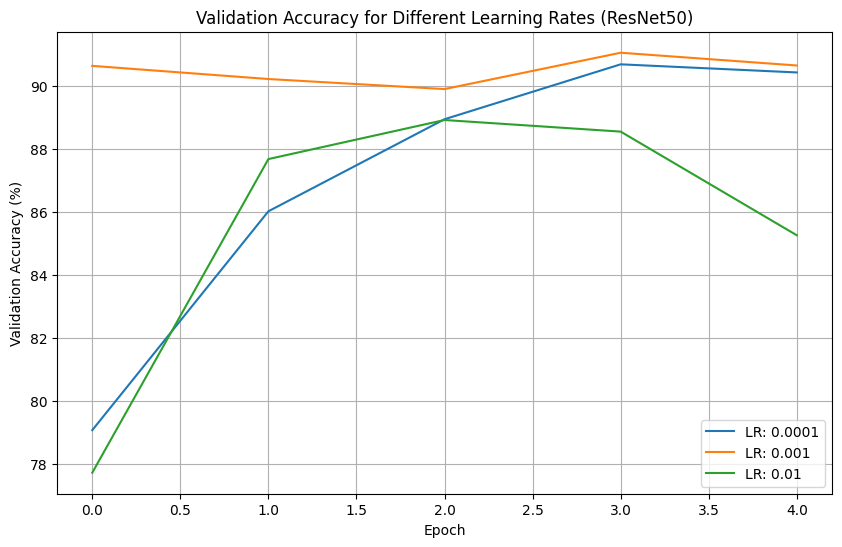

In [16]:
plt.figure(figsize=(10, 6))

for lr, accuracies in results.items():
    plt.plot(accuracies, label=f'LR: {lr}')

plt.title('Validation Accuracy for Different Learning Rates (ResNet50)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()